In [16]:
import pandas as pd 
df=pd.read_csv('metadata_premier_league_1415.xls')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 531 entries, 0 to 530
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            531 non-null    int64  
 1   player_name   531 non-null    object 
 2   games         531 non-null    int64  
 3   time          531 non-null    int64  
 4   goals         531 non-null    int64  
 5   xG            531 non-null    float64
 6   assists       531 non-null    int64  
 7   xA            531 non-null    float64
 8   shots         531 non-null    int64  
 9   key_passes    531 non-null    int64  
 10  yellow_cards  531 non-null    int64  
 11  red_cards     531 non-null    int64  
 12  position      531 non-null    object 
 13  team_title    531 non-null    object 
 14  npg           531 non-null    int64  
 15  npxG          531 non-null    float64
 16  xGChain       531 non-null    float64
 17  xGBuildup     531 non-null    float64
 18  league_ratio  531 non-null    

In [18]:
#Xar bir oyin uchun o'rtacha gollar soni----- oyinchini stabilligini korish
df['gpg']=df['goals']/df['games']

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 531 entries, 0 to 530
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            531 non-null    int64  
 1   player_name   531 non-null    object 
 2   games         531 non-null    int64  
 3   time          531 non-null    int64  
 4   goals         531 non-null    int64  
 5   xG            531 non-null    float64
 6   assists       531 non-null    int64  
 7   xA            531 non-null    float64
 8   shots         531 non-null    int64  
 9   key_passes    531 non-null    int64  
 10  yellow_cards  531 non-null    int64  
 11  red_cards     531 non-null    int64  
 12  position      531 non-null    object 
 13  team_title    531 non-null    object 
 14  npg           531 non-null    int64  
 15  npxG          531 non-null    float64
 16  xGChain       531 non-null    float64
 17  xGBuildup     531 non-null    float64
 18  league_ratio  531 non-null    

In [20]:
df['ypg']=df['yellow_cards']/df['games']   #intizom boyucha 

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 531 entries, 0 to 530
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            531 non-null    int64  
 1   player_name   531 non-null    object 
 2   games         531 non-null    int64  
 3   time          531 non-null    int64  
 4   goals         531 non-null    int64  
 5   xG            531 non-null    float64
 6   assists       531 non-null    int64  
 7   xA            531 non-null    float64
 8   shots         531 non-null    int64  
 9   key_passes    531 non-null    int64  
 10  yellow_cards  531 non-null    int64  
 11  red_cards     531 non-null    int64  
 12  position      531 non-null    object 
 13  team_title    531 non-null    object 
 14  npg           531 non-null    int64  
 15  npxG          531 non-null    float64
 16  xGChain       531 non-null    float64
 17  xGBuildup     531 non-null    float64
 18  league_ratio  531 non-null    

In [22]:
df['XGDIFF']=df['xG']-df['goals']

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 531 entries, 0 to 530
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            531 non-null    int64  
 1   player_name   531 non-null    object 
 2   games         531 non-null    int64  
 3   time          531 non-null    int64  
 4   goals         531 non-null    int64  
 5   xG            531 non-null    float64
 6   assists       531 non-null    int64  
 7   xA            531 non-null    float64
 8   shots         531 non-null    int64  
 9   key_passes    531 non-null    int64  
 10  yellow_cards  531 non-null    int64  
 11  red_cards     531 non-null    int64  
 12  position      531 non-null    object 
 13  team_title    531 non-null    object 
 14  npg           531 non-null    int64  
 15  npxG          531 non-null    float64
 16  xGChain       531 non-null    float64
 17  xGBuildup     531 non-null    float64
 18  league_ratio  531 non-null    

# Classes


In [24]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

class Datapreprocessing:
    def __init__(self, df):
        self.df = df.copy()
    
    # Handle missing values
    def tozala(self):
        for col in self.df.columns:
            if self.df[col].isnull().any():
                if self.df[col].dtype == 'object':
                    self.df[col].fillna(self.df[col].mode()[0], inplace=True)
                else:
                    self.df[col].fillna(self.df[col].mean(), inplace=True)
        return self
    
    # Encode categorical variables
    def encodla(self):
        encoder = LabelEncoder()
        for col in self.df.columns:
            if self.df[col].dtype == 'object':
                if self.df[col].nunique() <= 5:  # few categories → OneHot
                    dummies = pd.get_dummies(self.df[col], prefix=col, dtype=int)
                    self.df = pd.concat([self.df.drop(columns=[col]), dummies], axis=1)
                else:  # many categories → Label Encoding
                    self.df[col] = encoder.fit_transform(self.df[col])
        return self
    
    # Scale numeric features
    def scale_qil(self):
        scaler = MinMaxScaler()
        num_cols = self.df.select_dtypes(include=['int64', 'float64']).columns.drop('xG', errors='ignore')
        self.df[num_cols] = scaler.fit_transform(self.df[num_cols])
        return self
    
    # Log transformation for skewed features
    def log_transform(self, threshold=0.5):
        skewness = self.df.skew()
        features_log = skewness[(skewness >= threshold)].index.tolist()
        
        for col in features_log:
            if (self.df[col] > 0).all():  # only positive values
                self.df[col] = np.log1p(self.df[col])
        return self


In [25]:
processor = Datapreprocessing(df)

df_ready = (
    processor
    .tozala()
    .encodla()
    .scale_qil()
    .log_transform()
    .df
)

print(df_ready.head())


         id  player_name     games      time     goals         xG   assists  \
0  0.119973     0.864151  0.864865  0.745832  1.000000  25.270160  0.444444   
1  0.126264     0.375472  0.891892  0.756946  0.807692  17.157292  0.222222   
2  0.161087     0.250943  0.675676  0.617140  0.769231  15.219104  0.166667   
3  0.171422     0.154717  0.918919  0.899971  0.692308  17.881850  0.277778   
4  0.092788     0.045283  0.918919  0.867505  0.615385  13.451750  0.444444   

         xA     shots  key_passes  ...  position  team_title       npg  \
0  0.495505  1.000000        0.33  ...  0.615385    0.594595  1.000000   
1  0.349011  0.756757        0.27  ...  0.538462    0.945946  0.904762   
2  0.405260  0.513514        0.41  ...  0.615385    0.243243  0.904762   
3  0.226779  0.885135        0.23  ...  0.384615    0.729730  0.714286   
4  0.755785  0.824324        0.82  ...  0.538462    0.000000  0.761905   

       npxG   xGChain  xGBuildup  league_ratio       gpg       ypg    XGDIFF  
0

In [26]:
df=df_ready

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 531 entries, 0 to 530
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            531 non-null    float64
 1   player_name   531 non-null    float64
 2   games         531 non-null    float64
 3   time          531 non-null    float64
 4   goals         531 non-null    float64
 5   xG            531 non-null    float64
 6   assists       531 non-null    float64
 7   xA            531 non-null    float64
 8   shots         531 non-null    float64
 9   key_passes    531 non-null    float64
 10  yellow_cards  531 non-null    float64
 11  red_cards     531 non-null    float64
 12  position      531 non-null    float64
 13  team_title    531 non-null    float64
 14  npg           531 non-null    float64
 15  npxG          531 non-null    float64
 16  xGChain       531 non-null    float64
 17  xGBuildup     531 non-null    float64
 18  league_ratio  531 non-null    

# Filter Methods

In [13]:
# Correlation
import numpy as np

corr_matrix = df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.8)]
df_filtered = df.drop(columns=to_drop)
print("\nOriginal shape:", df.shape)
print("Shape after dropping correlated features:", df_filtered.shape)



Original shape: (531, 22)
Shape after dropping correlated features: (531, 12)


In [15]:
import numpy as np

corr_matrix = df.corr().abs()
corr_matrix

,id,player_name,games,time,goals,xG,assists,xA,shots,key_passes,...,position,team_title,npg,npxG,xGChain,xGBuildup,league_ratio,gpg,ypg,XGDIFF
id,1.000000,0.063216,0.353923,0.377964,0.204249,0.208180,0.221928,0.238378,0.226919,0.228006,...,0.132448,0.014828,0.208642,0.216759,0.330784,0.346400,NaN,0.199892,0.107423,0.041729
player_name,0.063216,1.000000,0.021318,0.019087,0.013106,0.000019,0.051767,0.050280,0.000572,0.046560,...,0.002571,0.011477,0.025877,0.010815,0.025214,0.023977,NaN,0.015710,0.030470,0.037402
games,0.353923,0.021318,1.000000,0.950374,0.451165,0.482719,0.482539,0.572401,0.586120,0.615808,...,0.289466,0.016912,0.453866,0.492398,0.688121,0.665799,NaN,0.365167,0.180701,0.032641
time,0.377964,0.019087,0.950374,1.000000,0.388074,0.409214,0.437392,0.524935,0.505356,0.572175,...,0.357195,0.016568,0.386865,0.413270,0.645165,0.676854,NaN,0.289908,0.197985,0.043701
goals,0.204249,0.013106,0.451165,0.388074,1.000000,0.937133,0.479416,0.569092,0.859816,0.551249,...,0.024936,0.014775,0.987934,0.925110,0.733690,0.397162,NaN,0.950505,0.063268,0.418059
xG,0.208180,0.000019,0.482719,0.409214,0.937133,1.000000,0.521906,0.601487,0.911589,0.571692,...,0.011082,0.019936,0.914506,0.988832,0.770199,0.394524,NaN,0.875737,0.061639,0.074763
assists,0.221928,0.051767,0.482539,0.437392,0.479416,0.521906,1.000000,0.872633,0.618619,0.819032,...,0.040705,0.016863,0.462360,0.511665,0.730626,0.592408,NaN,0.410252,0.110405,0.011360
xA,0.238378,0.050280,0.572401,0.524935,0.569092,0.601487,0.872633,1.000000,0.709398,0.950232,...,0.024139,0.030949,0.558139,0.596773,0.854837,0.695407,NaN,0.488396,0.111768,0.060454
shots,0.226919,0.000572,0.586120,0.505356,0.859816,0.911589,0.618619,0.709398,1.000000,0.713562,...,0.020845,0.007440,0.848447,0.910648,0.816547,0.496173,NaN,0.789724,0.099542,0.083971
key_passes,0.228006,0.046560,0.615808,0.572175,0.551249,0.571692,0.819032,0.950232,0.713562,1.000000,...,0.000249,0.010497,0.542656,0.568104,0.835138,0.700929,NaN,0.467991,0.137336,0.087029


In [113]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 531 entries, 0 to 530
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            531 non-null    float64
 1   player_name   531 non-null    float64
 2   games         531 non-null    float64
 3   goals         531 non-null    float64
 4   assists       531 non-null    float64
 5   yellow_cards  531 non-null    float64
 6   red_cards     531 non-null    float64
 7   position      531 non-null    float64
 8   team_title    531 non-null    float64
 9   league_ratio  531 non-null    float64
 10  ypg           531 non-null    float64
 11  XGDIFF        531 non-null    float64
dtypes: float64(12)
memory usage: 49.9 KB


In [114]:
#More analysis
import seaborn as sns
import matplotlib.pyplot as plt
corr_matrix = df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.8)]

In [115]:
corr_matrix = df.corr().abs()
print(corr_matrix)

                    id  player_name     games      time     goals        xG  \
id            1.000000     0.063216  0.353923  0.377964  0.204249  0.208180   
player_name   0.063216     1.000000  0.021318  0.019087  0.013106  0.000019   
games         0.353923     0.021318  1.000000  0.950374  0.451165  0.482719   
time          0.377964     0.019087  0.950374  1.000000  0.388074  0.409214   
goals         0.204249     0.013106  0.451165  0.388074  1.000000  0.937133   
xG            0.208180     0.000019  0.482719  0.409214  0.937133  1.000000   
assists       0.221928     0.051767  0.482539  0.437392  0.479416  0.521906   
xA            0.238378     0.050280  0.572401  0.524935  0.569092  0.601487   
shots         0.226919     0.000572  0.586120  0.505356  0.859816  0.911589   
key_passes    0.228006     0.046560  0.615808  0.572175  0.551249  0.571692   
yellow_cards  0.249212     0.040467  0.601368  0.606807  0.272495  0.281658   
red_cards     0.066108     0.016725  0.211680  0.230

In [116]:
high_corr_pairs = []
for col in upper.columns:
    for row in upper.index:
        if upper.loc[row, col] is not np.nan and upper.loc[row, col] > 0.85:
            high_corr_pairs.append([row, col, round(upper.loc[row, col], 2)])

corr_table = pd.DataFrame(high_corr_pairs, columns=['Feature 1', 'Feature 2', 'Correlation'])
print("Highly correlated feature pairs (correlation > 0.8):")
print(corr_table)


Highly correlated feature pairs (correlation > 0.8):
   Feature 1   Feature 2  Correlation
0      games        time         0.95
1      goals          xG         0.94
2    assists          xA         0.87
3      goals       shots         0.86
4         xG       shots         0.91
5         xA  key_passes         0.95
6      goals         npg         0.99
7         xG         npg         0.91
8      goals        npxG         0.93
9         xG        npxG         0.99
10     shots        npxG         0.91
11       npg        npxG         0.92
12        xA     xGChain         0.85
13   xGChain   xGBuildup         0.86
14     goals         gpg         0.95
15        xG         gpg         0.88
16       npg         gpg         0.95
17      npxG         gpg         0.87


In [117]:
df_filtered = df.drop(columns=to_drop)
print("\nOriginal shape:", df.shape)
print("Shape after dropping correlated features:", df_filtered.shape)


Original shape: (531, 22)
Shape after dropping correlated features: (531, 12)


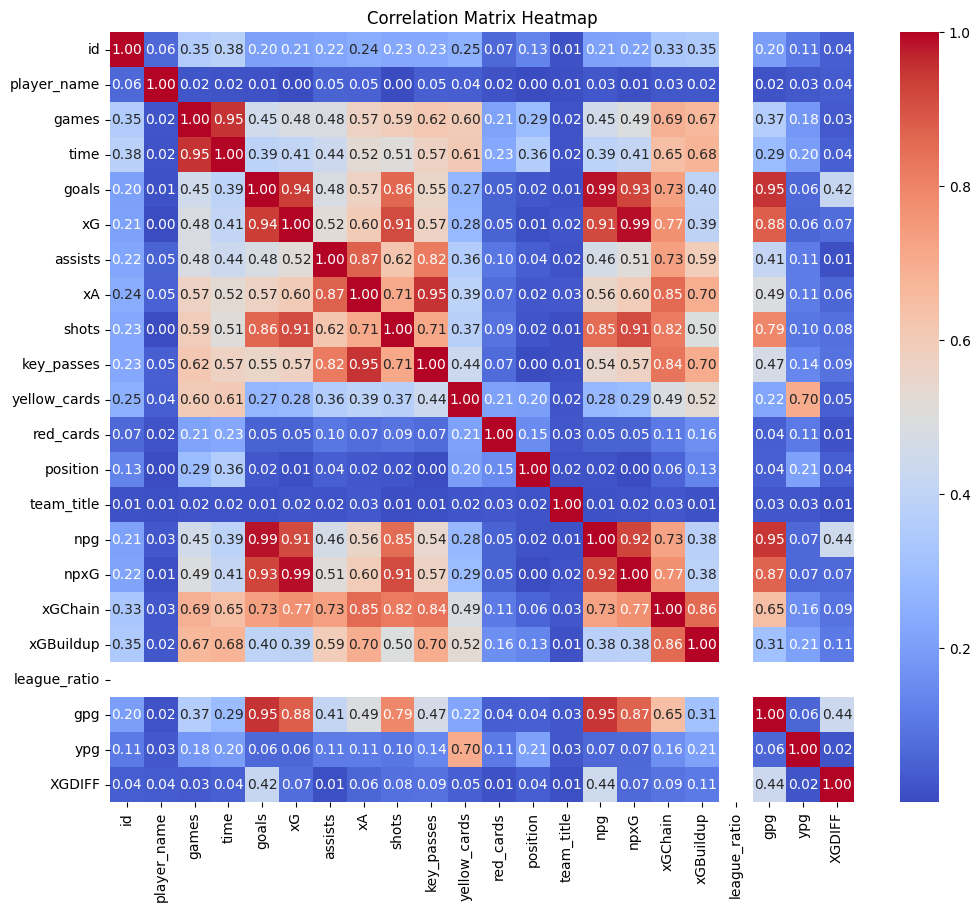

In [118]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix Heatmap")
plt.show()

In [120]:
import plotly.express as px

# Create a long-form dataframe for Plotly
corr_long = corr_matrix.reset_index().melt(id_vars='index')
corr_long.columns = ['Feature 1', 'Feature 2', 'Correlation']

# Interactive heatmap with Plotly Express
fig = px.imshow(
    corr_matrix,
    text_auto='.2f',          # show correlation values
    aspect="auto",
    color_continuous_scale='RdBu_r',  # red-blue reversed
    zmin=-1, zmax=1,
    title="Correlation Matrix Heatmap (Interactive)"
)

fig.update_layout(
    width=900,
    height=800,
    xaxis_title="Features",
    yaxis_title="Features"
)

fig.show()


In [121]:
#Low Vairance
from sklearn.feature_selection import VarianceThreshold

# Set threshold for variance (e.g., 0.01)
threshold = 0.01

# Initialize VarianceThreshold
selector = VarianceThreshold(threshold=threshold)

# Fit on the dataset
selector.fit(df_filtered)

# Features with low variance
low_variance_features = df_filtered.columns[~selector.get_support()]
print("Features with low variance (to drop):", list(low_variance_features))

# Drop low-variance features
df_low_variance_filtered = df_filtered.drop(columns=low_variance_features)
print("\nOriginal shape:", df_filtered.shape)
print("Shape after dropping low-variance features:", df_low_variance_filtered.shape)


Features with low variance (to drop): ['league_ratio', 'XGDIFF']

Original shape: (531, 12)
Shape after dropping low-variance features: (531, 10)


In [80]:
low_variance_features = df_filtered.columns[~selector.get_support()]
print("Features with low variance (to drop):", list(low_variance_features))

Features with low variance (to drop): ['league_ratio', 'XGDIFF']


In [122]:
#Ploty express
numeric_cols = df.select_dtypes(include=[np.number]).columns
variances = df[numeric_cols].var()

threshold = 0.01
low_variance_features = variances[variances < threshold].index.tolist()

var_df = pd.DataFrame({
    'Feature': variances.index,
    'Variance': variances.values,
    'LowVariance': ['Yes' if f in low_variance_features else 'No' for f in variances.index]
})


fig = px.bar(
    var_df,
    x='Feature',
    y='Variance',
    color='LowVariance',
    color_discrete_map={'Yes': 'red', 'No': 'blue'},
    text='Variance',
    title='Feature Variance (Low-Variance Highlighted in Red)'
)

fig.update_layout(
    xaxis_tickangle=-45,
    width=1000,
    height=600
)

fig.show()

In [82]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 531 entries, 0 to 530
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            531 non-null    float64
 1   player_name   531 non-null    float64
 2   games         531 non-null    float64
 3   goals         531 non-null    float64
 4   assists       531 non-null    float64
 5   yellow_cards  531 non-null    float64
 6   red_cards     531 non-null    float64
 7   position      531 non-null    float64
 8   team_title    531 non-null    float64
 9   league_ratio  531 non-null    float64
 10  ypg           531 non-null    float64
 11  XGDIFF        531 non-null    float64
dtypes: float64(12)
memory usage: 49.9 KB


In [ ]:
#Drop qilinishi kerak

In [123]:
# Recursev Feature Elimination
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

X = df.drop('xG', axis=1)
y = df['xG']




In [124]:
model = LinearRegression()
rfe = RFE(model, n_features_to_select=10)
rfe.fit(X, y)

selected_features = X.columns[rfe.support_]
print("Selected features:", selected_features)

Selected features: Index(['time', 'goals', 'assists', 'xA', 'shots', 'position', 'npg', 'npxG',
       'gpg', 'XGDIFF'],
      dtype='object')


In [125]:
# Embedded Methods 
#For linear models
from sklearn.linear_model import LassoCV
X = df.drop('xG', axis=1)
y = df['xG']
lasso = LassoCV(cv=10, random_state=42).fit(X, y)
importance = np.abs(lasso.coef_)


In [ ]:
selected_features = X.columns[importance > 0]

print("Selected features using Lasso (non-zero coefficients):")
print(selected_features.tolist())

Selected features using Lasso (non-zero coefficients):
['goals', 'shots', 'npxG', 'XGDIFF']


In [127]:
#faqat muhim  featurelarni saqlab qolish

percentile_threshold = np.percentile(importance, 75)  # top 25% features
top_features = X.columns[importance >= percentile_threshold]

print("\nTop 25% important features based on Lasso coefficients:")
print(top_features.tolist())


Top 25% important features based on Lasso coefficients:
['id', 'player_name', 'games', 'time', 'goals', 'assists', 'xA', 'shots', 'key_passes', 'yellow_cards', 'red_cards', 'position', 'team_title', 'npg', 'npxG', 'xGChain', 'xGBuildup', 'league_ratio', 'gpg', 'ypg', 'XGDIFF']


In [129]:
fig = px.bar(
    feat_df,
    x='Feature',
    y='Importance',
    color='Top25%',
    color_discrete_map={'Yes': 'red', 'No': 'blue'},
    text='Importance',
    title='Lasso Feature Importance'
)

fig.update_layout(
    xaxis_tickangle=-45,
    width=1000,
    height=600
)

fig.show()

In [133]:
# Tree based(Random Forest)
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=500, random_state=42)
rf.fit(X, y)
importances = rf.feature_importances_

# Create a DataFrame for feature importance
feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})
feat_df = feat_df.sort_values(by='Importance', ascending=False)

# Mark top 25% most important features
percentile_threshold = np.percentile(importances, 50)
feat_df['Top25%'] = np.where(feat_df['Importance'] >= percentile_threshold, 'Yes', 'No')

# Show table
print("Random Forest Feature Importance Table:")
print(feat_df)

Random Forest Feature Importance Table:
         Feature  Importance Top25%
14          npxG    0.952814    Yes
7          shots    0.010656    Yes
4          goals    0.009102    Yes
18           gpg    0.005083    Yes
13           npg    0.004432    Yes
0             id    0.002993    Yes
15       xGChain    0.001873    Yes
1    player_name    0.001857    Yes
8     key_passes    0.001676    Yes
2          games    0.001631    Yes
3           time    0.001368    Yes
6             xA    0.001248     No
20        XGDIFF    0.001179     No
12    team_title    0.001151     No
5        assists    0.001041     No
16     xGBuildup    0.000960     No
19           ypg    0.000430     No
11      position    0.000257     No
9   yellow_cards    0.000191     No
10     red_cards    0.000057     No
17  league_ratio    0.000000     No


In [132]:
importances

array([2.99282384e-03, 1.85664773e-03, 1.63079636e-03, 1.36821493e-03,
       9.10182740e-03, 1.04146245e-03, 1.24767688e-03, 1.06563470e-02,
       1.67632419e-03, 1.91492089e-04, 5.70853485e-05, 2.56702053e-04,
       1.15137319e-03, 4.43212680e-03, 9.52814129e-01, 1.87345815e-03,
       9.60150144e-04, 0.00000000e+00, 5.08311752e-03, 4.29635638e-04,
       1.17860888e-03])

In [134]:
fig = px.bar(
    feat_df,
    x='Feature',
    y='Importance',
    color='Top25%',
    color_discrete_map={'Yes': 'red', 'No': 'blue'},
    text='Importance',
    title='Random Forest Feature Importance'
)

fig.update_layout(
    xaxis_tickangle=-45,
    width=1000,
    height=600
)

fig.show()


# Ensemble  methods

In [28]:
# Bagging(Random Forest)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 531 entries, 0 to 530
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            531 non-null    float64
 1   player_name   531 non-null    float64
 2   games         531 non-null    float64
 3   time          531 non-null    float64
 4   goals         531 non-null    float64
 5   xG            531 non-null    float64
 6   assists       531 non-null    float64
 7   xA            531 non-null    float64
 8   shots         531 non-null    float64
 9   key_passes    531 non-null    float64
 10  yellow_cards  531 non-null    float64
 11  red_cards     531 non-null    float64
 12  position      531 non-null    float64
 13  team_title    531 non-null    float64
 14  npg           531 non-null    float64
 15  npxG          531 non-null    float64
 16  xGChain       531 non-null    float64
 17  xGBuildup     531 non-null    float64
 18  league_ratio  531 non-null    

In [29]:
from sklearn.model_selection import train_test_split


In [31]:
x=df.drop('xG',axis=1)

In [32]:
y=df['xG']

In [33]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [34]:
from sklearn.ensemble import RandomForestRegressor
model=RandomForestRegressor()

In [35]:
model

RandomForestRegressor()

In [36]:
model.fit(x_train,y_train)

RandomForestRegressor()

In [37]:
y_pred=model.predict(x_test)

In [38]:
y_pred

array([9.12504347e-01, 9.06752877e+00, 1.32560808e+00, 1.05309776e-01,
       2.28896299e-01, 9.69646261e-01, 2.54059630e+00, 4.06384111e+00,
       3.77413067e-01, 0.00000000e+00, 0.00000000e+00, 5.89516109e-01,
       8.04659604e+00, 1.29547720e+00, 5.11198710e+00, 7.63329881e+00,
       0.00000000e+00, 1.50777767e+01, 3.49438668e-01, 6.64552595e-02,
       1.41924116e+00, 6.82491220e-02, 2.25844243e-01, 0.00000000e+00,
       3.03497225e-01, 1.42299993e+00, 2.46683015e+00, 1.08061692e+00,
       1.54478298e+00, 1.36445293e-02, 1.62801208e+00, 3.04110420e-01,
       8.09286616e-01, 2.38091218e+00, 3.82906040e-01, 4.28022149e+00,
       2.60595501e+00, 7.51002514e-01, 1.19377204e+00, 8.97089682e+00,
       5.20489595e+00, 1.12918032e-01, 4.29035815e+00, 1.15383953e+00,
       1.73096416e+00, 1.69622500e-02, 1.30209350e-02, 8.06705848e+00,
       1.16301140e+00, 0.00000000e+00, 2.50881386e-01, 4.59068830e+00,
       2.64424040e+00, 1.88950015e+00, 4.19930577e+00, 9.44241655e-01,
      

In [39]:
from sklearn.metrics import r2_score, mean_absolute_error

In [40]:
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
print(r2)
print(mae)

0.9207970105381498
0.2915849728502801


# Boosting(XGBoost)

In [41]:
#pip install xgboost

In [42]:
import xgboost as xgb

In [43]:
xgb

<module 'xgboost' from 'C:\\Users\\davro\\AppData\\Roaming\\Python\\Python312\\site-packages\\xgboost\\__init__.py'>

In [46]:
model=xgb.XGBRegressor()

In [47]:
model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [64]:
model=xgb.XGBRegressor(n_estimators=120, learning_rate=0.1,max_depth=5, subsample=0.8,colsample_bytree=0.8, random_state=42)

In [65]:
model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=120,
             n_jobs=None, num_parallel_tree=None, ...)

In [66]:
model.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=120,
             n_jobs=None, num_parallel_tree=None, ...)

In [67]:
model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=120,
             n_jobs=None, num_parallel_tree=None, ...)

In [68]:
y_pred=model.predict(x_test)

In [69]:
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
print(r2)
print(mae)

0.935025327680048
0.2802478974525587


In [63]:
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
print(r2)
print(mae)

0.9337814576722799
0.3103780101416746


In [54]:
from sklearn.tree import DecisionTreeRegressor
model=DecisionTreeRegressor()

In [55]:
model.fit(x_train,y_train)

DecisionTreeRegressor()

In [56]:
y_pred=model.predict(x_test)

In [57]:
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
print(r2)
print(mae)

0.9431453673614375
0.26210650469158875
